In [7]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

In [8]:
mnist = fetch_openml("mnist_784", version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


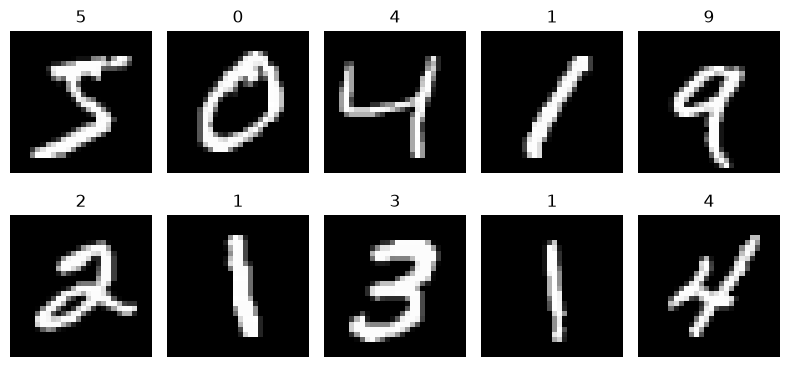

In [9]:
plt.figure(figsize=(8,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X[i].reshape(28,28), cmap="gray")
    plt.title(y[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
scaler = MinMaxScaler()

X = scaler.fit_transform(X)

print(X.min())
print(X.max())

0.0
1.0


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(56000, 784)
(14000, 784)


In [12]:
pca = PCA(n_components=4)

X_train_pca = pca.fit_transform(X_train)

X_test_pca = pca.transform(X_test)

In [13]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal explained variance:")
print(np.sum(pca.explained_variance_ratio_))

Explained variance ratio:
[0.09726115 0.07140175 0.06141646 0.05412974]

Total explained variance:
0.28420910531623267


In [14]:
import os

os.makedirs("../data", exist_ok=True)

np.save("../data/X_train.npy", X_train_pca)
np.save("../data/X_test.npy", X_test_pca)

np.save("../data/y_train.npy", y_train)
np.save("../data/y_test.npy", y_test)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.
